# Konfiguracja

In [52]:
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

## Dane

In [53]:
# 1. Wczytaj zbiór danych
housing_data = fetch_california_housing()

# 2. Zapisz cechy w DataFrame X, a zmienną docelową w Series y
X = pd.DataFrame(housing_data.data, columns=housing_data.feature_names)
y = pd.Series(housing_data.target)

print("Zbiór danych został pomyślnie wczytany.")

# 3. Wyświetl pierwsze 5 wierszy X oraz sprawdź jego wymiar i typy danych
print("\nPierwsze 5 wierszy X:")
display(X.head())
print("\nWymiar X:", X.shape)
print("\nTypy danych w X:\n", X.dtypes)

# 4. Sprawdź brakujące wartości w zbiorze danych
print("\nBrakujące wartości w X:\n", X.isnull().sum())

# 6. Podziel dane na zbiory treningowy i testowy
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("\nDane zostały podzielone na zbiór treningowy i testowy.")
print("Wymiar X_train:", X_train.shape)
print("Wymiar X_test:", X_test.shape)
print("Wymiar y_train:", y_train.shape)
print("Wymiar y_test:", y_test.shape)

Zbiór danych został pomyślnie wczytany.

Pierwsze 5 wierszy X:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25



Wymiar X: (20640, 8)

Typy danych w X:
 MedInc        float64
HouseAge      float64
AveRooms      float64
AveBedrms     float64
Population    float64
AveOccup      float64
Latitude      float64
Longitude     float64
dtype: object

Brakujące wartości w X:
 MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
dtype: int64

Dane zostały podzielone na zbiór treningowy i testowy.
Wymiar X_train: (16512, 8)
Wymiar X_test: (4128, 8)
Wymiar y_train: (16512,)
Wymiar y_test: (4128,)


### EDA

Pamiętasz wykład o eksploracyjnej analizie danych? To też element wyjaśnialnej sztucznej inteligencji :)

In [ ]:
# TODO

## Model

In [11]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import accuracy_score, classification_report

# 1. Utwórz model RandomForestRegressor
model = RandomForestRegressor(random_state=42)

# 2. Wytrenuj model
model.fit(X_train, y_train)

print("Model RandomForestRegressor został pomyślnie wytrenowany.")

# 3. Wykonaj predykcje na zbiorze testowym
y_pred = model.predict(X_test)


Model RandomForestRegressor został pomyślnie wytrenowany.


In [12]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
import numpy as np

# Calculate regression metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)

print(f"\nMean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R2): {r2:.4f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.4f}")



Mean Absolute Error (MAE): 0.3275
Mean Squared Error (MSE): 0.2554
Root Mean Squared Error (RMSE): 0.5053
R-squared (R2): 0.8051
Mean Absolute Percentage Error (MAPE): 0.1892


# LIME

## Wyjaśnienie kolejnych kroków algorytmu

In [20]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression

# 1. Wybór obserwacji do wyjaśnienia
instance = X_test.iloc[0]
instance_df = instance.to_frame().T

print("\nObserwacja do wyjaśnienia:\n", instance.head(), "\n")

# 2. Predykcja modelu (wartość ciągła)
prediction = model.predict(instance_df)[0]

print("Przewidywana wartość:", prediction, "\n")

# 3. Generowanie zaburzonych próbek
def perturb(x, n=1000, strength=0.01):
    noise = np.random.normal(0, strength, (n, len(x))) * X_train.std().values
    return pd.DataFrame(x.values + noise, columns=x.index)

perturbed = perturb(instance, strength=0.01)

print(f"Wygenerowano {len(perturbed)} próbek.\n")

# 4. Predykcje dla zaburzonych danych (ciągłe wartości)
preds = model.predict(perturbed)

# 5. Wagi – kernel Gaussowski (jak w LIME)
def kernel(dist, width=0.75):
    return np.exp(-(dist**2) / width**2)

distances = np.linalg.norm(perturbed.values - instance.values, axis=1)
weights = kernel(distances)

print("Przykładowe wagi:\n", weights[:5], "\n")

# 6. Dopasowanie lokalnego modelu liniowego
local_model = LinearRegression()
local_model.fit(perturbed, preds, sample_weight=weights)

print("Model lokalny dopasowany.\n")

# 7. Ważność cech
importance = pd.DataFrame({
    "Cecha": X_train.columns,
    "Wpływ": local_model.coef_
}).sort_values(by="Wpływ", key=abs, ascending=False)

print("Najważniejsze cechy:\n")
print(importance.head(10))


Obserwacja do wyjaśnienia:
 MedInc           1.681200
HouseAge        25.000000
AveRooms         4.192201
AveBedrms        1.022284
Population    1392.000000
Name: 20046, dtype: float64 

Przewidywana wartość: 0.5094999999999998 

Wygenerowano 1000 próbek.

Przykładowe wagi:
 [1.09334460e-01 3.84418932e-02 8.91075555e-03 1.16341419e-04
 1.83811356e-07] 

Model lokalny dopasowany.

Najważniejsze cechy:

        Cecha     Wpływ
3   AveBedrms -0.868195
2    AveRooms  0.079463
7   Longitude -0.075996
0      MedInc  0.067603
5    AveOccup -0.065491
6    Latitude  0.054614
1    HouseAge -0.013878
4  Population -0.001417


## Użycie gotowych bibliotek

In [23]:
pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 20.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=0b259471636d465c362ad780de50fb4cdac8e34a42efa035a90f1dfb877ea1fe
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [25]:
from lime.lime_tabular import LimeTabularExplainer
import os
import pandas as pd

# 1. Utworzenie eksplainera LIME (dla regresji)
explainer = LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X_train.columns.tolist(),
    mode='regression'
)

print("LimeTabularExplainer został pomyślnie utworzony.\n")

# 2. Wybór obserwacji do wyjaśnienia
instance_for_lime = instance.values  # zamiana na numpy

# Funkcja opakowująca model (dla klasyfikacji używamy predict_proba zamiast predict)
def predict_wrapper(data):
    data_df = pd.DataFrame(data, columns=X_train.columns)
    return model.predict(data_df)

# 3. Generowanie wyjaśnienia
explanation = explainer.explain_instance(
    data_row=instance_for_lime,
    predict_fn=predict_wrapper,
    num_features=10  # pokaż 10 najważniejszych cech
)

print("Wyjaśnienie LIME zostało wygenerowane.\n")

# 4. Wyświetlenie wyjaśnienia (cecha + wpływ)
print("Wyjaśnienie LIME (10 najważniejszych cech):\n")
for feature, weight in explanation.as_list():
    print(f"  {feature}: {weight:.4f}")

# 5. Zapis do pliku HTML
output_dir = 'lime_explanations'
os.makedirs(output_dir, exist_ok=True)  # uproszczenie

file_path = os.path.join(output_dir, 'lime_explanation.html')
explanation.save_to_file(file_path)

print(f"\nWyjaśnienie zapisano do pliku: {file_path}")

LimeTabularExplainer został pomyślnie utworzony.

Wyjaśnienie LIME zostało wygenerowane.

Wyjaśnienie LIME (10 najważniejszych cech):

  MedInc <= 2.57: -0.8512
  AveOccup > 3.28: -0.3600
  34.26 < Latitude <= 37.72: -0.2382
  -121.81 < Longitude <= -118.51: 0.0965
  1.01 < AveBedrms <= 1.05: -0.0843
  AveRooms <= 4.45: -0.0616
  1167.00 < Population <= 1726.00: -0.0184
  18.00 < HouseAge <= 29.00: 0.0062

Wyjaśnienie zapisano do pliku: lime_explanations/lime_explanation.html


# SHAP

In [26]:
pip install shap

In [27]:
import shap

# Utworzenie obiektu SHAP TreeExplainer
explainer = shap.TreeExplainer(model, X_train)

print("SHAP TreeExplainer został pomyślnie zainicjalizowany.")

SHAP TreeExplainer został pomyślnie zainicjalizowany.


## Wyjaśnienia lokalne


Obserwacja z X_test (index 3) do wyjaśnienia SHAP (waterfall):
MedInc           5.737600
HouseAge        17.000000
AveRooms         6.163636
AveBedrms        1.020202
Population    1705.000000
Name: 20484, dtype: float64

Wartości SHAP dla wybranej obserwacji zostały obliczone.

Wartość oczekiwana modelu: 1.9758
Generowanie wykresu SHAP waterfall dla tej obserwacji...



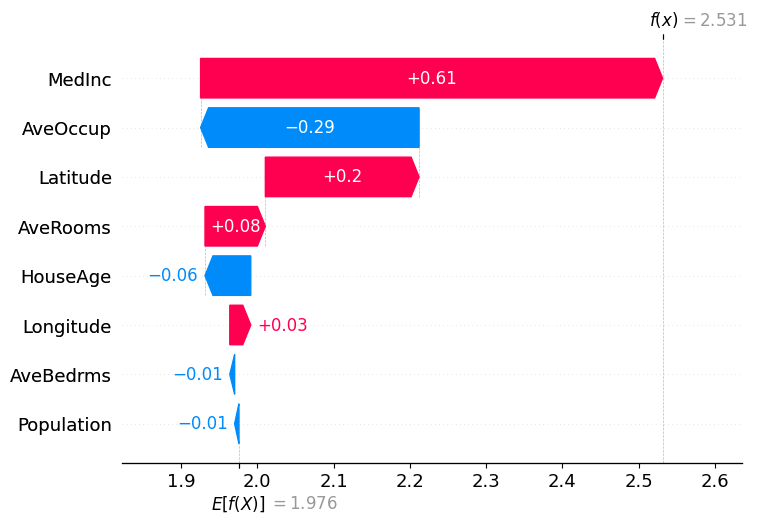

In [50]:
import shap
import matplotlib.pyplot as plt

# 1. Wybór obserwacji do wyjaśnienia (pierwsza obserwacja z X_test)
instance_index = 3
instance_to_explain = X_test.iloc[instance_index]
print(f"\nObserwacja z X_test (index {instance_index}) do wyjaśnienia SHAP (waterfall):\n{instance_to_explain.head()}\n")

# 2. Obliczenie wartości SHAP dla tej obserwacji
shap_values_instance = explainer.shap_values(instance_to_explain.to_frame().T)
expected_value = explainer.expected_value

print("Wartości SHAP dla wybranej obserwacji zostały obliczone.\n")
print(f"Wartość oczekiwana modelu: {expected_value:.4f}")

# 3. Generowanie wykresu typu waterfall (lokalny wpływ cech)
print("Generowanie wykresu SHAP waterfall dla tej obserwacji...\n")
shap.plots._waterfall.waterfall_legacy(
    expected_value=expected_value,
    shap_values=shap_values_instance[0],
    feature_names=X_test.columns,
    max_display=10  # pokaż maksymalnie 10 najważniejszych cech
)
plt.show()


Obserwacja z X_test (index 3) do wyjaśnienia SHAP:
MedInc           5.737600
HouseAge        17.000000
AveRooms         6.163636
AveBedrms        1.020202
Population    1705.000000
Name: 20484, dtype: float64

Wartości SHAP zostały obliczone pomyślnie.
Wartość oczekiwana modelu: 1.9758

Przewidywana wartość modelu dla tej obserwacji: 2.5296



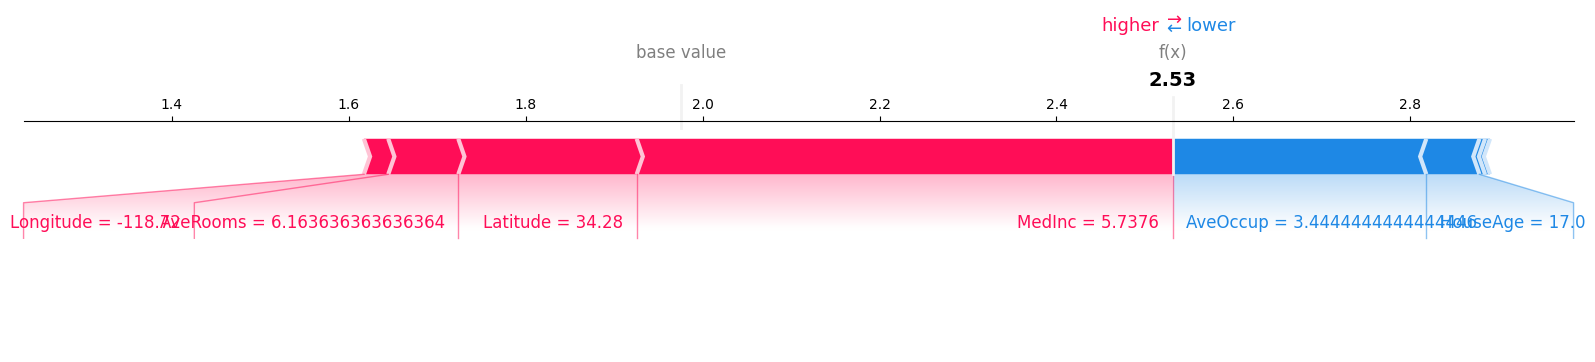

In [51]:
import shap

# Inicjalizacja JavaScript dla wykresów SHAP
shap.initjs()

# 1. Wybór obserwacji do wyjaśnienia (pierwsza obserwacja z X_test)
instance_index = 3
instance_to_explain = X_test.iloc[instance_index]
print(f"\nObserwacja z X_test (index {instance_index}) do wyjaśnienia SHAP:\n{instance_to_explain.head()}\n")

# 2. Obliczenie wartości SHAP dla tej obserwacji
# Dla regresji shap_values zwraca tablicę wartości SHAP dla wszystkich cech
shap_values = explainer.shap_values(instance_to_explain.to_frame().T)

# 3. Wartość oczekiwana modelu (base value)
expected_value = explainer.expected_value
print("Wartości SHAP zostały obliczone pomyślnie.")
print(f"Wartość oczekiwana modelu: {expected_value:.4f}\n")

# 4. Predykcja modelu dla tej obserwacji
prediction = model.predict(instance_to_explain.to_frame().T)[0]
print(f"Przewidywana wartość modelu dla tej obserwacji: {prediction:.4f}\n")

# 5. Wizualizacja lokalnego wyjaśnienia (force plot)
shap.force_plot(
    base_value=expected_value,
    shap_values=shap_values[0],  # shap_values dla jednej obserwacji
    features=instance_to_explain,
    matplotlib=True  # wyświetlenie wykresu w notebooku
)

## Wyjaśnienia globalne

In [34]:
# 1. Obliczenie wartości SHAP dla całego zbioru X_test
# Dla TreeExplainer regresji shap_values zwraca tablicę 2D: (liczba próbek, liczba cech)
shap_values_test = explainer.shap_values(X_test[:100], check_additivity=False)

print("Wartości SHAP dla całego zbioru X_test zostały pomyślnie obliczone.")
print(f"Wymiar tablicy shap_values_test: {shap_values_test.shape}")

 98%|===================| 98/100 [00:14<00:00]       

Wartości SHAP dla całego zbioru X_test zostały pomyślnie obliczone.
Wymiar tablicy shap_values_test: (100, 8)


Generowanie wykresu podsumowującego SHAP (dot plot)...



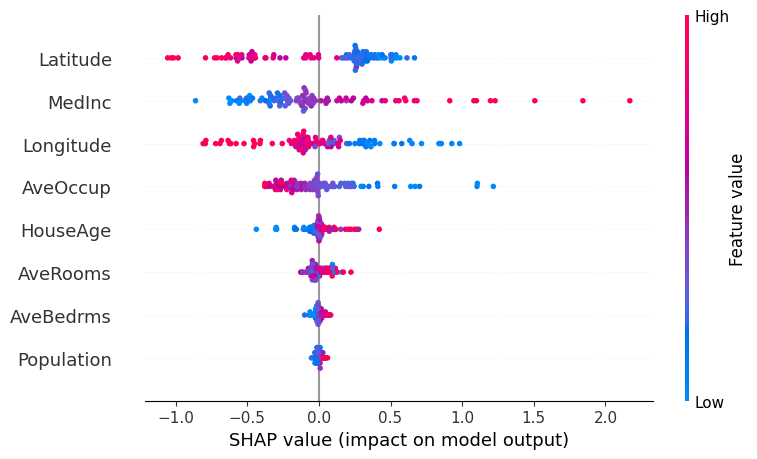


Generowanie wykresu podsumowującego SHAP (bar plot)...



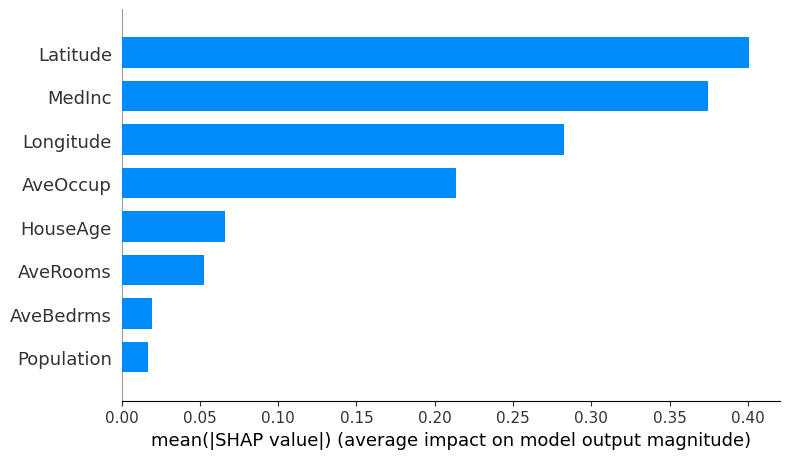

In [36]:
import shap
import matplotlib.pyplot as plt

# 1. Utworzenie i wyświetlenie wykresu SHAP summary (dot plot)
print("Generowanie wykresu podsumowującego SHAP (dot plot)...\n")
shap.summary_plot(shap_values_test, X_test[:100], show=False)
plt.tight_layout()
plt.show()

# 2. Opcjonalnie: wykres słupkowy dla średnich wartości bezwzględnych SHAP
print("\nGenerowanie wykresu podsumowującego SHAP (bar plot)...\n")
shap.summary_plot(shap_values_test, X_test, plot_type="bar", show=False)
plt.tight_layout()
plt.show()